1. Menyiapkan Libray

In [2]:
import pandas as pd
from transformers import pipeline

d:\Dokumen coding\Data Science\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2. Membangun mesin analisis sentimen

In [3]:
model_nlp = "mdhugol/indonesia-bert-sentiment-classification"

mesin_sentimen = pipeline(
    task='sentiment-analysis',
    model=model_nlp,
    tokenizer=model_nlp,
    truncation=True,
    max_length=128
)

def analisis_sentimen(teks):
    try:
        hasil_labeling = mesin_sentimen(teks)
        return hasil_labeling[0]['label']
    except Exception as e:
        return "ERORR"

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 34035.33it/s]


3. Siapkan dataset

In [4]:
data_komentar = pd.read_csv('data/dataset komentar bersih.csv')

df = pd.DataFrame(data_komentar)
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Tanggal   2225 non-null   str  
 1   Komentar  2225 non-null   str  
dtypes: str(2)
memory usage: 34.9 KB
None


mengubah tipe data tanggal ke date time dan membuat dataframe baru nya

In [5]:
try:
    df['Tanggal format'] = pd.to_datetime(df['Tanggal'], errors='coerce', dayfirst=True)
    print(df.info())
except Exception as e:
    print(f"terjadi error saat format tanggal : {e}")

<class 'pandas.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Tanggal         2225 non-null   str           
 1   Komentar        2225 non-null   str           
 2   Tanggal format  2225 non-null   datetime64[us]
dtypes: datetime64[us](1), str(2)
memory usage: 52.3 KB
None


C:\Users\Asus VivoBook Go 14\AppData\Local\Temp\ipykernel_5576\1413213258.py:2: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['Tanggal format'] = pd.to_datetime(df['Tanggal'], errors='coerce', dayfirst=True)


In [6]:
df_komentar = df[['Tanggal format', 'Komentar']]
print(df_komentar.info())

<class 'pandas.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Tanggal format  2225 non-null   datetime64[us]
 1   Komentar        2225 non-null   str           
dtypes: datetime64[us](1), str(1)
memory usage: 34.9 KB
None


In [7]:
print("Sedang memproses sentimen")
df_komentar['Label IndoBERT'] = df_komentar['Komentar'].apply(analisis_sentimen)

Sedang memproses sentimen


In [8]:
print("Hasil analisis sentimen\n")
print(df_komentar[['Komentar', 'Label IndoBERT']].head())

Hasil analisis sentimen

                                            Komentar Label IndoBERT
0  oalah bentar juga bubar srimulat x kud aja bub...        LABEL_2
1  Kopdes merah putih itu akan menghabisi pedagan...        LABEL_2
2  Tidak akan bertahan lama bangkrut besar pasak ...        LABEL_2
3  Kami yakin jadi bangunan mangkrak tiap kelurah...        LABEL_2
4                                            ABS😂😂😂😂        LABEL_0


In [9]:
print(df_komentar.info())

<class 'pandas.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Tanggal format  2225 non-null   datetime64[us]
 1   Komentar        2225 non-null   str           
 2   Label IndoBERT  2225 non-null   str           
dtypes: datetime64[us](1), str(2)
memory usage: 52.3 KB
None


5. Visualisasi labeling

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns


C:\Users\Asus VivoBook Go 14\AppData\Local\Temp\ipykernel_5576\199026357.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_komentar,


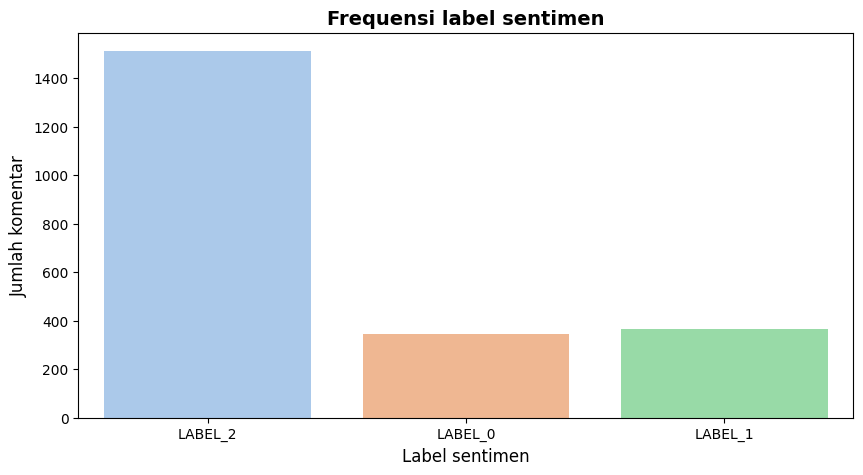

In [11]:
plt.figure(figsize=(10, 5))

sns.countplot(data=df_komentar, 
    x=df_komentar['Label IndoBERT'],
    palette='pastel'                    
)

plt.title("Frequensi label sentimen", fontsize=14, fontweight='bold')
plt.xlabel("Label sentimen", fontsize=12)
plt.ylabel("Jumlah komentar", fontsize=12)

plt.show()

6. Merubah nama labeling

In [12]:
kamus_sentimen = {
    'LABEL_0': 'Netral',
    'LABEL_1': 'Positif',
    'LABEL_2': 'Negatif'
}

df_komentar['Label IndoBERT'] = df_komentar['Label IndoBERT'].map(kamus_sentimen)
print(df_komentar.head())

  Tanggal format                                           Komentar  \
0     2026-06-30  oalah bentar juga bubar srimulat x kud aja bub...   
1     2026-06-30  Kopdes merah putih itu akan menghabisi pedagan...   
2     2026-06-30  Tidak akan bertahan lama bangkrut besar pasak ...   
3     2026-06-30  Kami yakin jadi bangunan mangkrak tiap kelurah...   
4     2026-06-29                                            ABS😂😂😂😂   

  Label IndoBERT  
0        Negatif  
1        Negatif  
2        Negatif  
3        Negatif  
4         Netral  


C:\Users\Asus VivoBook Go 14\AppData\Local\Temp\ipykernel_5576\199026357.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_komentar,


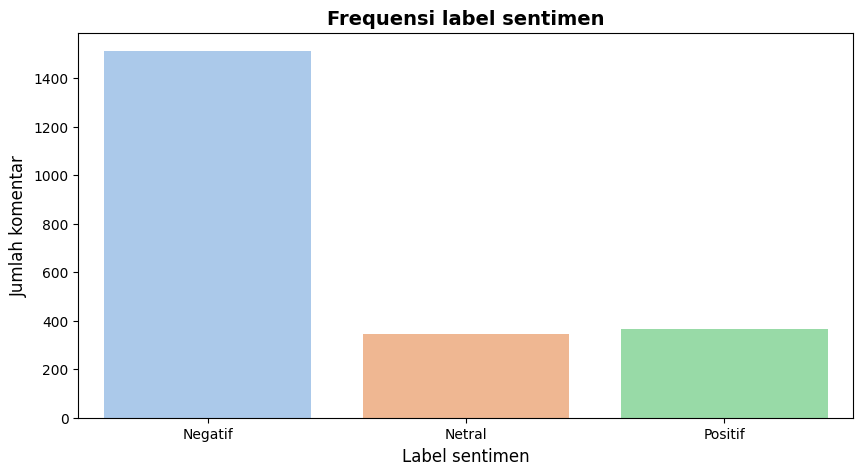

In [13]:
plt.figure(figsize=(10, 5))

sns.countplot(data=df_komentar, 
    x=df_komentar['Label IndoBERT'],
    palette='pastel'                    
)

plt.title("Frequensi label sentimen", fontsize=14, fontweight='bold')
plt.xlabel("Label sentimen", fontsize=12)
plt.ylabel("Jumlah komentar", fontsize=12)

plt.show()

In [14]:
# Mengambil 10 baris acak dari datamu
sampel_cek = df_komentar[['Komentar', 'Label IndoBERT']].sample(10)

# Menampilkan hasilnya agar bisa dibaca satu per satu
for index, baris in sampel_cek.iterrows():
    print(f"Komentar : {baris['Komentar']}")
    print(f"Prediksi : {baris['Label IndoBERT']}")
    print("-" * 50)

Komentar : Dua program unggulan yg diperkirakan 90% GA-TOT
Prediksi : Positif
--------------------------------------------------
Komentar : Nunggu bangkrutnya
Prediksi : Negatif
--------------------------------------------------
Komentar : Bangsa yg tidak instropeksi KUD ,. ? KOPINDO , ? KPN ( Koperasi Pewagai Negeri) ? Ribuan thn dijajah londo ireng Runtuhnya kerajaan 2 Jawa kuno punahnya ajaran Budi Luhur punahnya budaya adi Luhung punahnya huruf Jawa punahnya basa Jawa
Prediksi : Negatif
--------------------------------------------------
Komentar : Ramai banget , sampai tempat parkirnya gak muat.
Prediksi : Negatif
--------------------------------------------------
Komentar : Yang diresmikan Presiden lokasi jalan raya saja sepi, apalagi kdmp yang di desa berdiri ditengah hutan dan sawah jalan kampung dan mati, sudah pasti setelah proyek selesai keberlanjutanya adalah mangkrak ???
Prediksi : Negatif
--------------------------------------------------
Komentar : Bener 3 item itu yg bik

In [16]:
df_komentar.to_csv('data/dataset komentar labelling.csv', index=False, encoding='utf-8')
print("data berhasil disimpan")

data berhasil disimpan
